In [ ]:
# ========================================
# PRAKTIKUM: REAL-TIME VIDEO ENHANCEMENT
# ========================================

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [ ]:
class RealTimeEnhancement:

    def __init__(self, target_fps=30):
        self.target_fps = target_fps
        self.history_buffer = []

    def enhance_frame(self, frame, enhancement_type='adaptive'):

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if enhancement_type == 'contrast':
            enhanced = cv2.equalizeHist(gray)

        elif enhancement_type == 'denoise':
            enhanced = cv2.GaussianBlur(gray,(5,5),0)

        elif enhancement_type == 'sharpen':
            kernel = np.array([[0,-1,0],
                               [-1,5,-1],
                               [0,-1,0]])
            enhanced = cv2.filter2D(gray,-1,kernel)

        elif enhancement_type == 'adaptive':
            clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

        else:
            enhanced = gray

        self.history_buffer.append(enhanced)

        if len(self.history_buffer) > 5:
            self.history_buffer.pop(0)

        avg_frame = np.mean(self.history_buffer, axis=0).astype(np.uint8)

        return avg_frame

In [ ]:
def take_photo():

  js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => setTimeout(resolve, 500));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    takePhoto();
  ''')

  display(js)
  data = eval_js('takePhoto()')
  binary = b64decode(data.split(',')[1])

  return binary

<IPython.core.display.Javascript object>

Frame: 1


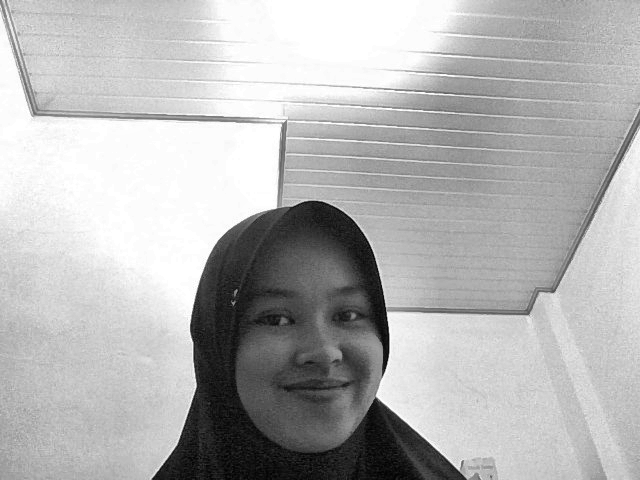

<IPython.core.display.Javascript object>

Frame: 2


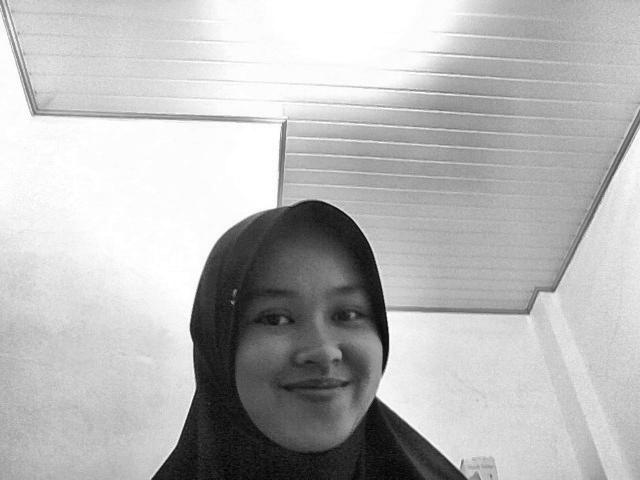

<IPython.core.display.Javascript object>

Frame: 3


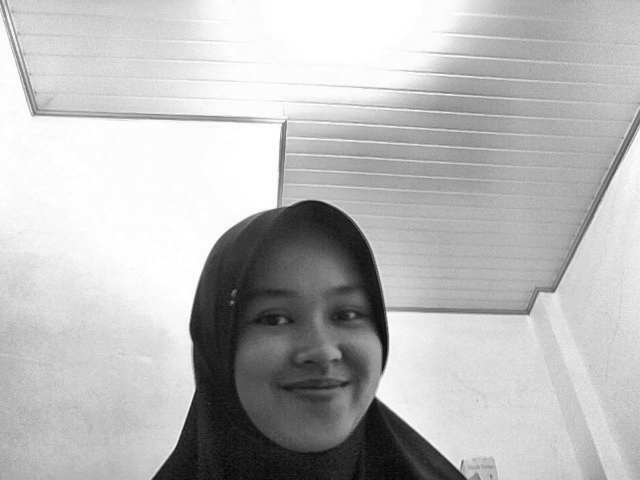

<IPython.core.display.Javascript object>

Frame: 4


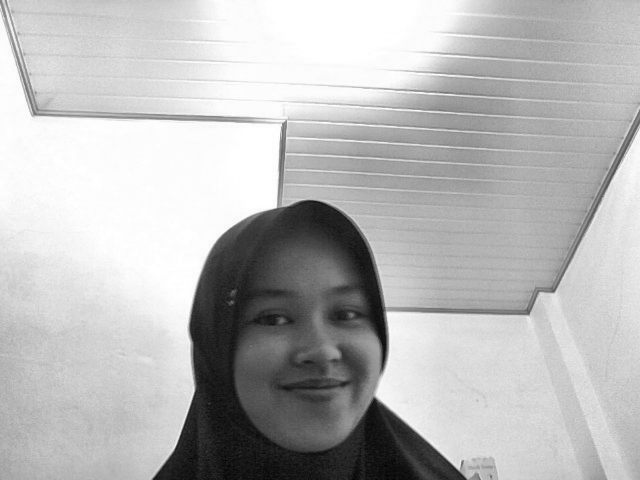

<IPython.core.display.Javascript object>

Frame: 5


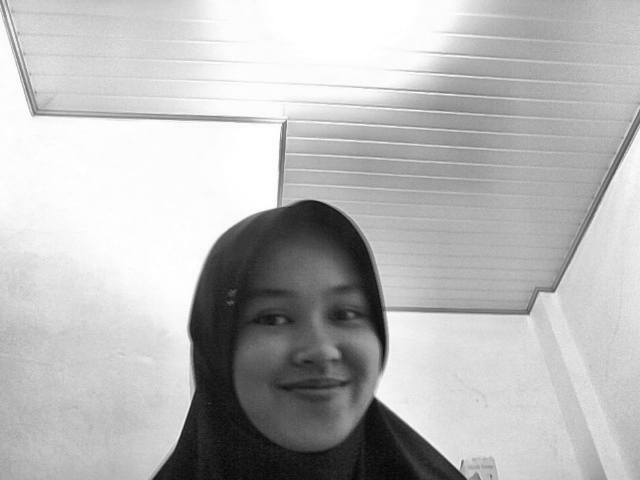

<IPython.core.display.Javascript object>

Frame: 6


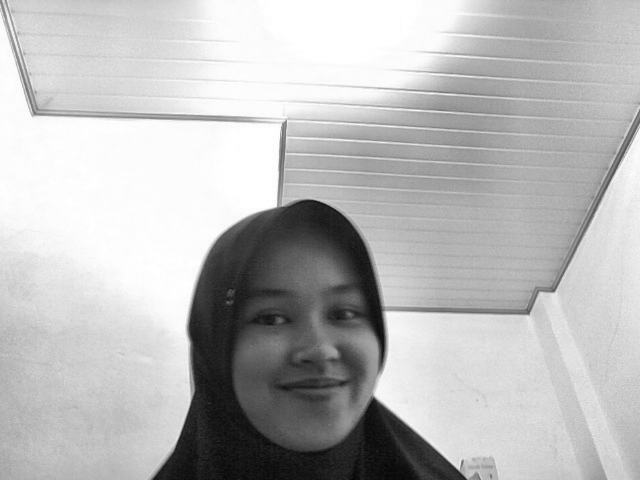

<IPython.core.display.Javascript object>

Frame: 7


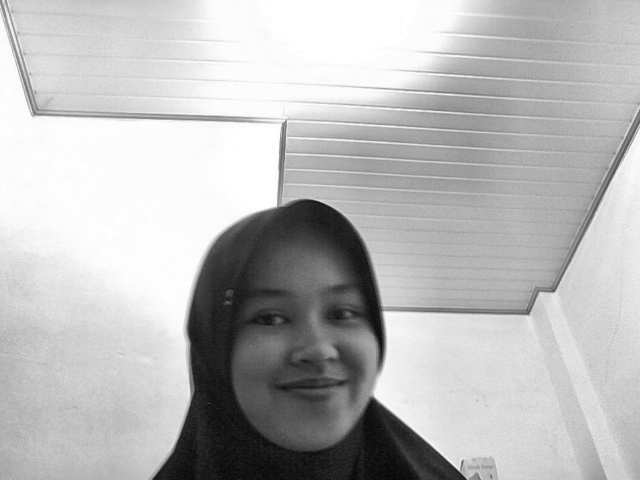

<IPython.core.display.Javascript object>

Frame: 8


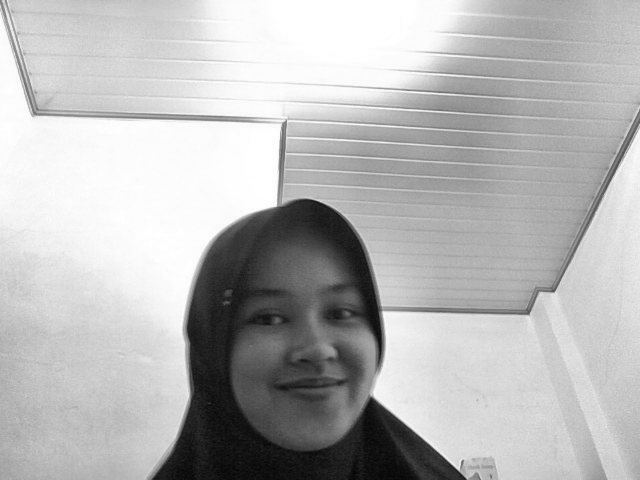

<IPython.core.display.Javascript object>

Frame: 9


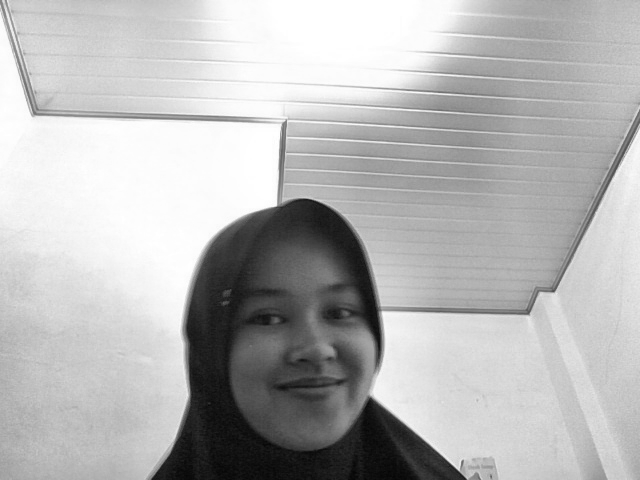

<IPython.core.display.Javascript object>

Frame: 10


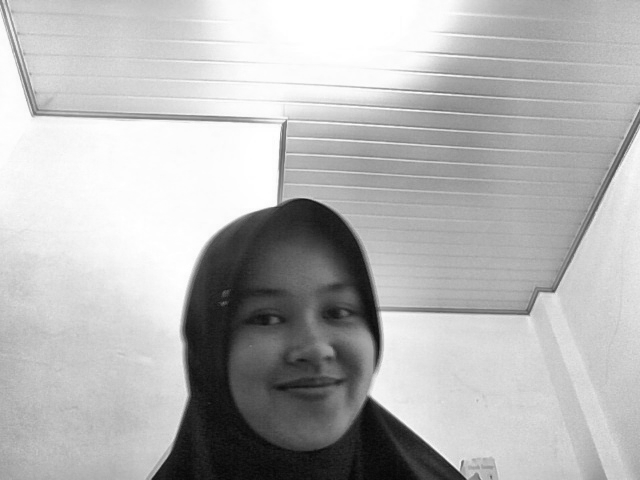

In [ ]:
enhancer = RealTimeEnhancement(target_fps=30)

for i in range(10):

    image_bytes = take_photo()

    npimg = np.frombuffer(image_bytes, np.uint8)
    frame = cv2.imdecode(npimg, cv2.IMREAD_COLOR)

    enhanced_frame = enhancer.enhance_frame(frame, 'adaptive')

    print("Frame:", i+1)

    cv2_imshow(enhanced_frame)